# **Old Photograph Restoration Using Image Enhancement and Noise Removal**

## **Introduction**

Old photographs often suffer from noise, fading, poor contrast, scratches, and loss of image quality due to aging and repeated handling.

This project aims to restore old photographs using Digital Image Processing techniques. Different image enhancement and noise removal methods are applied and compared to improve the visual quality of the photographs.

The project uses traditional image processing techniques such as median filtering, Gaussian filtering, histogram equalization, CLAHE, and Laplacian sharpening.

## **1. Dataset Download**

The dataset used in this project is the **Vintage Photo Restoration Clean and Damaged Image** dataset from Kaggle.

The dataset contains vintage photographs, including clean and damaged images. KaggleHub is used to download the dataset directly into Google Colab, so no manual downloading or uploading is required.

In [2]:
# Install KaggleHub
!pip -q install kagglehub
# Import KaggleHub
import kagglehub
# Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "shrutimandaokar2301/vintage-photo-restoration-clean-and-damaged-image"
)
print("Dataset downloaded successfully!")
print("Dataset path:", dataset_path)

100%|██████████| 18.5M/18.5M [00:00<00:00, 87.1MB/s]

Extracting files...
Dataset downloaded successfully!
Dataset path: /root/.cache/kagglehub/datasets/shrutimandaokar2301/vintage-photo-restoration-clean-and-damaged-image/versions/1


## **2. Exploring the Datase**t

Before processing the photographs, we will inspect the downloaded dataset to understand its folder structure and identify the locations of the clean and damaged images.

In [3]:
import os
# Display the contents of the dataset folder
print("Dataset contents:")
for item in os.listdir(dataset_path):
    print(item)

Dataset contents:
image_classification_results.csv
02_Damaged_Testing_Set
01_Clean_Candidates_GT


## **3. Dataset Image Count**

The dataset contains separate folders for clean reference images and damaged testing images.

In this step, we will count the images in each folder and identify the image formats available in the dataset.

In [4]:
# Define the clean and damaged image folders
clean_path = os.path.join(dataset_path, "01_Clean_Candidates_GT")
damaged_path = os.path.join(dataset_path, "02_Damaged_Testing_Set")

# Get image files
clean_images = [
    f for f in os.listdir(clean_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
damaged_images = [
    f for f in os.listdir(damaged_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of clean images:", len(clean_images))
print("Number of damaged images:", len(damaged_images))
print("\nClean image formats:")
print(set(os.path.splitext(f)[1].lower() for f in clean_images))
print("\nDamaged image formats:")
print(set(os.path.splitext(f)[1].lower() for f in damaged_images))

Number of clean images: 146
Number of damaged images: 54

Clean image formats:
{'.jpg'}

Damaged image formats:
{'.jpg'}


## **4. Visualizing Sample Images**

In this step, we will display a few clean and damaged photographs from the dataset.

This helps us understand the type of image degradation present in the dataset before applying restoration techniques.

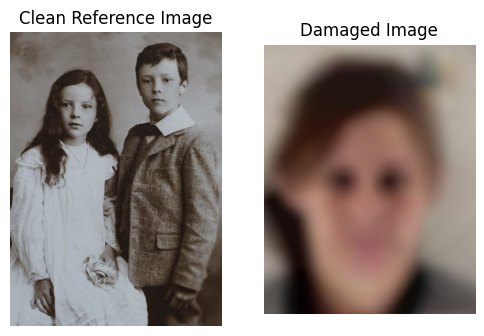

In [20]:
import cv2
import matplotlib.pyplot as plt

# Select the first image from each folder
clean_file = clean_images[0]
damaged_file = damaged_images[0]

# Read the images
clean_image = cv2.imread(os.path.join(clean_path, clean_file))
damaged_image = cv2.imread(os.path.join(damaged_path, damaged_file))

# Convert BGR to RGB for displaying with Matplotlib
clean_image = cv2.cvtColor(clean_image, cv2.COLOR_BGR2RGB)
damaged_image = cv2.cvtColor(damaged_image, cv2.COLOR_BGR2RGB)

# Display the images
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean_image)
plt.title("Clean Reference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(damaged_image)
plt.title("Damaged Image")
plt.axis("off")

plt.show()

## **5. Checking Image Pairing**

The clean and damaged images will be checked to determine whether corresponding images are available in both folders.

Matching image pairs are useful because the clean image can be used as a reference when evaluating the restored damaged image.

In [6]:
# Display the filenames of a few images from both folders

print("Clean images:")
for file in clean_images[:10]:
    print(file)

print("\nDamaged images:")
for file in damaged_images[:10]:
    print(file)

Clean images:
low-resolution-photographs_img122.jpg
low-resolution-photographs_img60.jpg
low-resolution-photographs_img121.jpg
low-resolution-photographs_img39.jpg
low-resolution-photographs_img29.jpg
low-resolution-photographs_img13.jpg
low-resolution-photographs_img102.jpg
low-resolution-photographs_img112.jpg
low-resolution-photographs_img77.jpg
low-resolution-photographs_img14.jpg

Damaged images:
low-resolution-photographs_img148.jpg
low-resolution-photographs_img136.jpg
low-resolution-photographs_img129.jpg
low-resolution-photographs_img3.jpg
low-resolution-photographs_img157.jpg
low-resolution-photographs_img34.jpg
low-resolution-photographs_img98.jpg
low-resolution-photographs_img146.jpg
low-resolution-photographs_img109.jpg
low-resolution-photographs_img154.jpg


## **6. Examining Dataset Information**

The dataset includes a CSV file containing information about the images.

We will inspect this file to determine whether it provides useful information about the clean and damaged photographs and their relationship.

In [7]:
import pandas as pd

# Load the dataset information
csv_path = os.path.join(dataset_path, "image_classification_results.csv")

df = pd.read_csv(csv_path)

# Display the first few rows
print("Number of rows:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Number of rows: 200

Columns:
['filename', 'classification']

First 10 rows:


,filename,classification
0,low-resolution-photographs_img1.jpg,DAMAGED_TESTING
1,low-resolution-photographs_img10.jpg,CLEAN_CANDIDATE
2,low-resolution-photographs_img100.jpg,CLEAN_CANDIDATE
3,low-resolution-photographs_img101.jpg,CLEAN_CANDIDATE
4,low-resolution-photographs_img102.jpg,CLEAN_CANDIDATE
5,low-resolution-photographs_img103.jpg,CLEAN_CANDIDATE
6,low-resolution-photographs_img104.jpg,CLEAN_CANDIDATE
7,low-resolution-photographs_img105.jpg,CLEAN_CANDIDATE
8,low-resolution-photographs_img106.jpg,CLEAN_CANDIDATE
9,low-resolution-photographs_img107.jpg,CLEAN_CANDIDATE


## **7. Selecting Images for the Project**

The dataset contains 146 clean candidate images and 54 damaged testing images.

For quantitative evaluation, a small number of clean images will be selected as reference images. Controlled degradation such as blur and noise will be added to these images. The restoration techniques will then be applied, and the restored images will be compared with their original clean versions.

A small subset will be used to keep the project simple and efficient.

In [8]:
# Select a small subset of clean images
selected_images = clean_images[:10]

print("Number of selected images:", len(selected_images))
print("\nSelected images:")

for image in selected_images:
    print(image)

Number of selected images: 10

Selected images:
low-resolution-photographs_img122.jpg
low-resolution-photographs_img60.jpg
low-resolution-photographs_img121.jpg
low-resolution-photographs_img39.jpg
low-resolution-photographs_img29.jpg
low-resolution-photographs_img13.jpg
low-resolution-photographs_img102.jpg
low-resolution-photographs_img112.jpg
low-resolution-photographs_img77.jpg
low-resolution-photographs_img14.jpg


## **8. Loading a Reference Image**

In this step, one clean reference photograph is loaded from the selected dataset.

The image dimensions will be checked and the photograph will be displayed to understand its original quality before applying degradation and restoration techniques.

Image name: low-resolution-photographs_img122.jpg
Image size: (695, 500, 3)


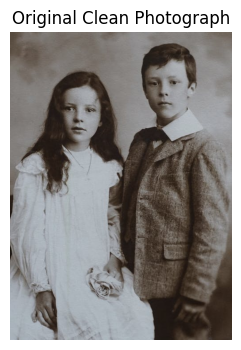

In [9]:
# Select the first reference image
image_file = selected_images[0]
# Load the image
image = cv2.imread(os.path.join(clean_path, image_file))
# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Display image information
print("Image name:", image_file)
print("Image size:", image.shape)
# Display the image
plt.figure(figsize=(6, 4))
plt.imshow(image_rgb)
plt.title("Original Clean Photograph")
plt.axis("off")
plt.show()

## **9. Applying Blur**

A stronger Gaussian blur is applied to make the image degradation more noticeable.

The original clean photograph is preserved as the reference image. The blurred image will be used as the input for the restoration techniques.

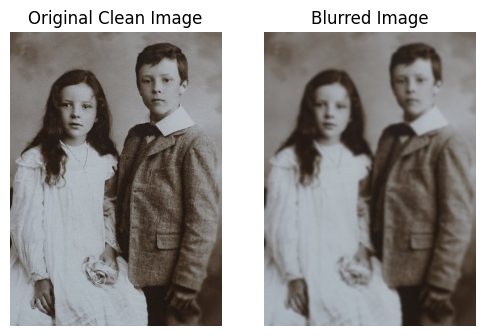

In [11]:
# Apply stronger Gaussian blur
blurred_image = cv2.GaussianBlur(image_rgb, (15, 15), 0)

# Display the original and blurred images
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Clean Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_image)
plt.title("Blurred Image")
plt.axis("off")

plt.show()

## **10. Restoration Using Median Filtering**

Median filtering is applied to the blurred photograph to reduce small unwanted variations and preserve important image edges.

A 5 × 5 median filter is used in this experiment. The result will be compared with the original blurred image.

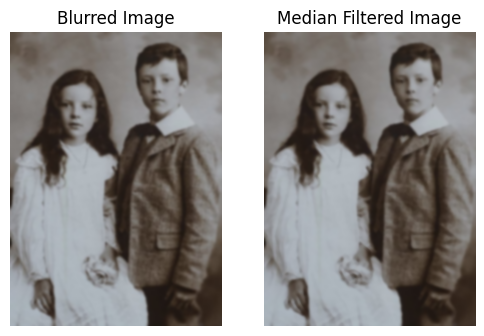

In [12]:
# Apply median filtering
median_restored = cv2.medianBlur(blurred_image, 5)

# Display the blurred and median-filtered images
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_image)
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(median_restored)
plt.title("Median Filtered Image")
plt.axis("off")

plt.show()

## **11. Restoration Using Laplacian Sharpening**

Laplacian sharpening is used to enhance edges and fine details in the blurred photograph.

The Laplacian operator detects rapid changes in intensity. By adding the detected details back to the blurred image, the sharpness of the photograph can be improved.

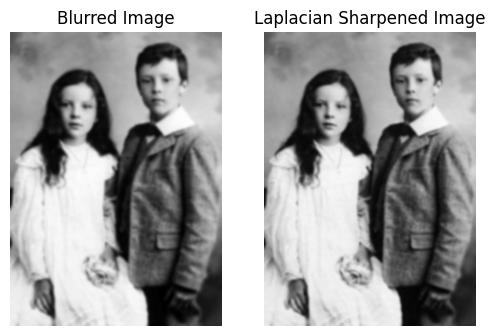

In [13]:
# Convert the blurred image to grayscale
blurred_gray = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2GRAY)

# Apply Laplacian operator
laplacian = cv2.Laplacian(blurred_gray, cv2.CV_64F)

# Create sharpened image
laplacian_sharpened = cv2.convertScaleAbs(blurred_gray - laplacian)

# Display the results
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_gray, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian_sharpened, cmap="gray")
plt.title("Laplacian Sharpened Image")
plt.axis("off")

plt.show()

## **12. Restoration Using Unsharp Masking**

Unsharp masking is used to enhance the fine details and edges of a blurred photograph.

The blurred image is first smoothed further, and the difference between the image and its smoothed version is used as a detail layer. This detail is then added back to the image to improve sharpness.

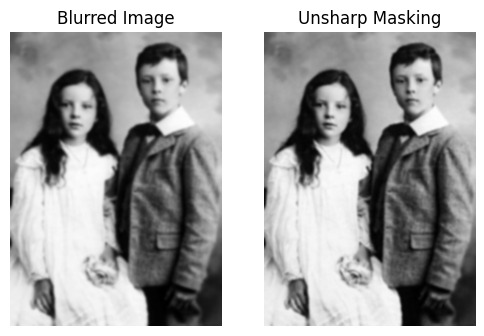

In [14]:
# Convert the blurred image to grayscale
blurred_gray = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2GRAY)

# Create a smoothed version
smooth = cv2.GaussianBlur(blurred_gray, (9, 9), 0)

# Apply unsharp masking
unsharp = cv2.addWeighted(blurred_gray, 2.0, smooth, -1.0, 0)

# Display the results
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_gray, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(unsharp, cmap="gray")
plt.title("Unsharp Masking")
plt.axis("off")

plt.show()

## **13. Restoration Using High-Boost Filtering**

High-boost filtering enhances the edges and fine details of an image by adding a stronger amount of high-frequency information to the original image.

In this experiment, the high-boost filter is applied to the blurred photograph to improve its sharpness.

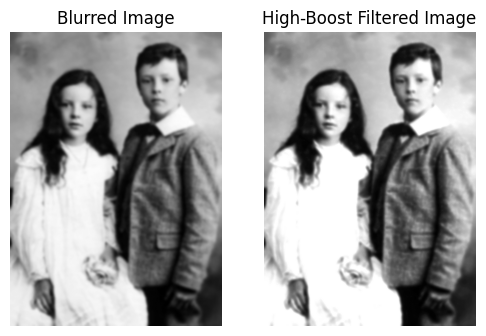

In [15]:
# Create a smoothed version of the blurred image
smooth = cv2.GaussianBlur(blurred_gray, (9, 9), 0)

# Calculate the detail mask
detail = cv2.subtract(blurred_gray, smooth)

# Apply high-boost filtering
high_boost = cv2.addWeighted(blurred_gray, 1.5, detail, 2.0, 0)

# Display the results
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(blurred_gray, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_boost, cmap="gray")
plt.title("High-Boost Filtered Image")
plt.axis("off")

plt.show()

## **14. Preserving the Original and Blurred Images**

To ensure consistent results, the original clean image and the blurred image are stored separately.

All restoration techniques will use the same blurred image as input. This prevents the output from changing when cells are run again.

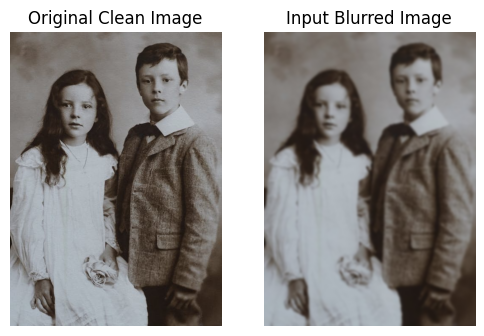

In [16]:
# Keep fixed copies of the original and blurred images
original_image = image_rgb.copy()
input_blurred = cv2.GaussianBlur(original_image, (15, 15), 0)

# Convert the blurred image to grayscale
input_blurred_gray = cv2.cvtColor(input_blurred, cv2.COLOR_RGB2GRAY)

# Display the fixed original and blurred images
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Clean Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(input_blurred)
plt.title("Input Blurred Image")
plt.axis("off")

plt.show()

## **15. Comparison of Restoration Results**

The results obtained from different restoration techniques are compared visually.

The original clean image, blurred image, and the images processed using median filtering, Laplacian sharpening, unsharp masking, and high-boost filtering are displayed together.

This comparison helps identify which technique provides better visual improvement.

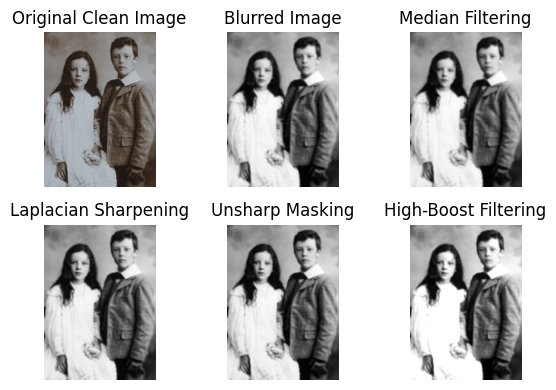

In [21]:
# Apply the restoration techniques to the fixed blurred image

# Median filtering
median_result = cv2.medianBlur(input_blurred_gray, 5)

# Laplacian sharpening
laplacian = cv2.Laplacian(input_blurred_gray, cv2.CV_64F)
laplacian_result = cv2.convertScaleAbs(
    input_blurred_gray - laplacian
)

# Unsharp masking
smooth = cv2.GaussianBlur(input_blurred_gray, (9, 9), 0)
unsharp_result = cv2.addWeighted(
    input_blurred_gray, 2.0, smooth, -1.0, 0
)

# High-boost filtering
detail = cv2.subtract(input_blurred_gray, smooth)
high_boost_result = cv2.addWeighted(
    input_blurred_gray, 1.5, detail, 2.0, 0
)

# Display all results
plt.figure(figsize=(6, 4))

plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title("Original Clean Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(input_blurred_gray, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(median_result, cmap="gray")
plt.title("Median Filtering")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(laplacian_result, cmap="gray")
plt.title("Laplacian Sharpening")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(unsharp_result, cmap="gray")
plt.title("Unsharp Masking")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(high_boost_result, cmap="gray")
plt.title("High-Boost Filtering")
plt.axis("off")

plt.tight_layout()
plt.show()

## **16. Contrast Enhancement**

Old photographs may appear faded or have low contrast because of aging and poor storage conditions.

In this step, two contrast enhancement techniques are applied to the blurred photograph:

- Histogram Equalization
- CLAHE (Contrast Limited Adaptive Histogram Equalization)

The results will be compared to determine which method provides better contrast enhancement.

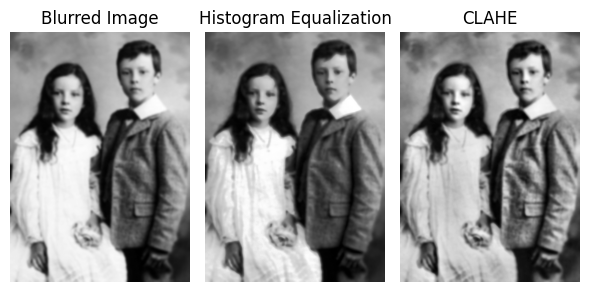

In [22]:
# Apply Histogram Equalization
hist_equalized = cv2.equalizeHist(input_blurred_gray)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE
clahe_result = clahe.apply(input_blurred_gray)

# Display the results
plt.figure(figsize=(6, 4))

plt.subplot(1, 3, 1)
plt.imshow(input_blurred_gray, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hist_equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(clahe_result, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

## **17. Combined Image Restoration**

The restoration techniques are now combined to produce an improved version of the blurred photograph.

Median filtering is used for basic noise reduction, CLAHE is used to improve contrast, and unsharp masking is used to enhance details and edges.

This combined approach aims to improve the overall visual quality of the old photograph.

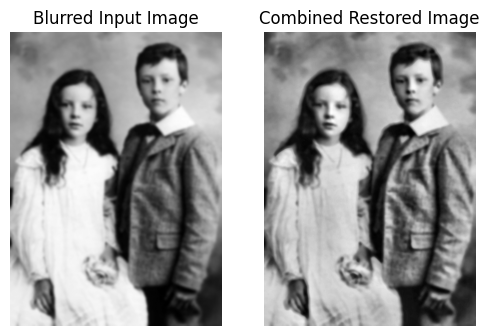

In [23]:
# Step 1: Reduce small noise
combined = cv2.medianBlur(input_blurred_gray, 3)

# Step 2: Improve contrast using CLAHE
combined = clahe.apply(combined)

# Step 3: Enhance edges using unsharp masking
smooth_combined = cv2.GaussianBlur(combined, (9, 9), 0)
combined_restored = cv2.addWeighted(
    combined, 1.5, smooth_combined, -0.5, 0
)

# Display the final restored image
plt.figure(figsize=(6, 4))

plt.subplot(1, 2, 1)
plt.imshow(input_blurred_gray, cmap="gray")
plt.title("Blurred Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(combined_restored, cmap="gray")
plt.title("Combined Restored Image")
plt.axis("off")

plt.show()

## **18. Quantitative Evaluation**

The restoration results are evaluated by comparing them with the original clean reference image.

Three commonly used image-quality metrics are calculated:

- **MSE (Mean Squared Error):** Measures the average squared difference between the original and restored images. Lower values indicate better results.
- **PSNR (Peak Signal-to-Noise Ratio):** Measures the quality of the restored image compared with the reference image. Higher values indicate better results.
- **SSIM (Structural Similarity Index):** Measures the similarity of structural information between the two images. Values closer to 1 indicate greater similarity.

In [24]:
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# Convert original image to grayscale
original_gray = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY)

# Store restoration results
results = {
    "Blurred": input_blurred_gray,
    "Median Filtering": median_result,
    "Laplacian Sharpening": laplacian_result,
    "Unsharp Masking": unsharp_result,
    "High-Boost Filtering": high_boost_result,
    "Combined Restoration": combined_restored
}

# Calculate metrics
evaluation = []

for method, result in results.items():
    mse = mean_squared_error(original_gray, result)
    psnr = peak_signal_noise_ratio(original_gray, result, data_range=255)
    ssim = structural_similarity(original_gray, result, data_range=255)

    evaluation.append([method, mse, psnr, ssim])

# Display results
evaluation_df = pd.DataFrame(
    evaluation,
    columns=["Method", "MSE", "PSNR (dB)", "SSIM"]
)

display(evaluation_df)

,Method,MSE,PSNR (dB),SSIM
0,Blurred,68.101511,29.799236,0.833277
1,Median Filtering,72.547914,29.524554,0.824180
2,Laplacian Sharpening,59.363839,30.395584,0.832794
3,Unsharp Masking,55.934829,30.653980,0.850991
4,High-Boost Filtering,3646.414576,12.512143,0.780408
5,Combined Restoration,636.284892,20.094287,0.803380


## **19. Testing Restoration on Multiple Images**

The same restoration techniques are applied to the 10 selected clean images.

For each image, a blurred version is created using Gaussian blur. The restoration methods are then applied and evaluated using MSE, PSNR, and SSIM.

The average results across all 10 images are calculated to compare the performance of the restoration techniques.

In [25]:
# Store results for all images
all_results = []

for image_name in selected_images:
    image_path = os.path.join(clean_path, image_name)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create blurred input
    blurred = cv2.GaussianBlur(img_rgb, (15, 15), 0)
    blurred_gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    original_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Restoration methods
    median = cv2.medianBlur(blurred_gray, 5)

    laplacian = cv2.Laplacian(blurred_gray, cv2.CV_64F)
    laplacian_result = cv2.convertScaleAbs(blurred_gray - laplacian)

    smooth = cv2.GaussianBlur(blurred_gray, (9, 9), 0)
    unsharp = cv2.addWeighted(blurred_gray, 2.0, smooth, -1.0, 0)

    detail = cv2.subtract(blurred_gray, smooth)
    high_boost = cv2.addWeighted(blurred_gray, 1.5, detail, 2.0, 0)

    combined = cv2.medianBlur(blurred_gray, 3)
    combined = clahe.apply(combined)
    smooth_combined = cv2.GaussianBlur(combined, (9, 9), 0)
    combined_result = cv2.addWeighted(
        combined, 1.5, smooth_combined, -0.5, 0
    )

    methods = {
        "Blurred": blurred_gray,
        "Median Filtering": median,
        "Laplacian Sharpening": laplacian_result,
        "Unsharp Masking": unsharp,
        "High-Boost Filtering": high_boost,
        "Combined Restoration": combined_result
    }

    for method, result in methods.items():
        mse = mean_squared_error(original_gray, result)
        psnr = peak_signal_noise_ratio(original_gray, result, data_range=255)
        ssim = structural_similarity(original_gray, result, data_range=255)

        all_results.append([method, mse, psnr, ssim])

# Create DataFrame
all_results_df = pd.DataFrame(
    all_results,
    columns=["Method", "MSE", "PSNR (dB)", "SSIM"]
)

# Calculate average results
average_results = all_results_df.groupby("Method").mean().reset_index()

display(average_results)

,Method,MSE,PSNR (dB),SSIM
0,Blurred,185.400078,26.951923,0.773203
1,Combined Restoration,654.736916,20.219821,0.741543
2,High-Boost Filtering,2651.346182,14.130237,0.709777
3,Laplacian Sharpening,159.345518,27.616879,0.783965
4,Median Filtering,197.483457,26.667985,0.760476
5,Unsharp Masking,154.320446,27.828367,0.799031


## **20. Visualization of Average Results**

The average PSNR values of the restoration methods are visualized using a bar graph.

A higher PSNR value indicates better restoration quality compared with the original clean image.

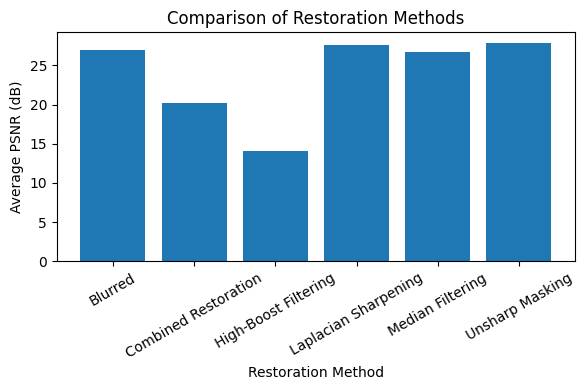

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.bar(
    average_results["Method"],
    average_results["PSNR (dB)"]
)

plt.xlabel("Restoration Method")
plt.ylabel("Average PSNR (dB)")
plt.title("Comparison of Restoration Methods")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 21. Results and Discussion

The restoration techniques were evaluated on 10 selected vintage photographs using MSE, PSNR, and SSIM.

The results show that Unsharp Masking achieved the best overall performance, with the lowest average MSE of 154.32, the highest average PSNR of 27.83 dB, and the highest average SSIM of 0.7990.

Laplacian Sharpening also performed well, with an average PSNR of 27.62 dB and SSIM of 0.7840.

Median Filtering showed limited improvement because it mainly performs smoothing and noise reduction rather than reversing blur.

High-Boost Filtering produced excessive enhancement and resulted in poor quantitative performance, with an average PSNR of 14.13 dB.

The Combined Restoration method also performed poorly quantitatively, with an average PSNR of 20.22 dB. Combining multiple enhancement operations introduced additional pixel-level changes.

Overall, Unsharp Masking was the most effective technique among the tested methods for the selected dataset and experimental setup.

## **22. Limitations**

The project has the following limitations:

- Gaussian blur was used to simulate image degradation rather than using paired real damaged and clean images.
- Traditional spatial filtering cannot fully recover details that are completely lost due to severe blur.
- The performance of the restoration methods depends on the selected filter parameters.
- High-Boost Filtering and the combined restoration method may produce excessive enhancement and unwanted changes in some images.
- The dataset contains a limited number of real damaged photographs for quantitative comparison.

## **23. Future Scope**

The project can be improved in the future by:

- Using advanced deblurring techniques to recover more details from severely blurred photographs.
- Applying automatic parameter selection for different types and levels of degradation.
- Combining noise removal, deblurring, and color restoration techniques.
- Using deep learning-based image restoration methods for better results.
- Testing the system on a larger collection of real damaged photographs.

## **24. Conclusion**

This project presented a simple image restoration approach for improving the quality of vintage photographs affected by blur and other degradation.

Different spatial filtering and enhancement techniques were implemented and compared using MSE, PSNR, and SSIM. Among the tested methods, Unsharp Masking achieved the best overall performance, with an average MSE of 154.32, PSNR of 27.83 dB, and SSIM of 0.7990 across 10 images.

The results show that simple image processing techniques can improve the sharpness and visual quality of degraded photographs. The project also demonstrated that different techniques perform differently depending on the type and severity of image degradation.

Overall, the project successfully demonstrates the application of digital image processing techniques for vintage photograph restoration and enhancement.